# **Evaluación: HybridCNN binario (`alertable`)**

Carga el modelo binario **`model_bi_V1`** y evalúa sobre el split `test`.

Produce:
- Accuracy, F1 macro/weighted y reporte por clase
- Matriz de confusión absoluta y normalizada
- Métricas específicas de clasificación binaria (Precision, Recall, AUC-ROC)
- Guardado automático de figuras en `FINAL_MODEL_DIR`

## **1. Importaciones**

In [1]:
from __future__ import annotations

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from tqdm import tqdm
from src.utils.config import (
    PROCESSED_METADATA,
    LABEL_MAPPING,
    FINAL_MODEL_DIR,
    CHECKPOINT_DIR,
)
# from src.models.hybrid_cnn_v3 import ImprovedMFCCCNN # modelo binario
from src.models.hybrid_cnn_v4 import HybridCNNV5 # modelo binario
from src.models.audio_dataset import ProcessedAudioDataset, crnn_collate_fn

print("Importaciones completadas.")

Importaciones completadas.


## **2. Configuración**

In [2]:
# ─────────────────────────────────────────────
# RUTAS
# ─────────────────────────────────────────────
# MODEL_PATH = FINAL_MODEL_DIR / "best_alertable_v4.pt"
# MODEL_PATH = FINAL_MODEL_DIR / "best_alertable_v4.pt"
MODEL_PATH = CHECKPOINT_DIR /"alertable_V4"/ "checkpoint_epoch_26.pt"
# MODEL_PATH = FINAL_MODEL_DIR / "model_bi_V1.pt" # modelo binario

LABEL_MAPPING_PATH = LABEL_MAPPING["alertable2"] # mapping binario
TARGET_TYPE = "alertable"

# ─────────────────────────────────────────────
# DATALOADER
# ─────────────────────────────────────────────
BATCH_SIZE = 48
NUM_WORKERS = 4
DROPOUT = 0.40

# ─────────────────────────────────────────────
# VISUALIZACIÓN (2×2 = figura más pequeña)
# ─────────────────────────────────────────────
FIG_SIZE = (7, 6) # la matriz 2×2 no necesita tanto espacio
ANNOT_ABSOLUTE = True
ANNOT_NORM = True
PROCESSED_METADATA=PROCESSED_METADATA['2']
print(f"- Modelo: {MODEL_PATH}")
print(f"- Label mapping: {LABEL_MAPPING_PATH}")
print(f"- Metadata CSV: {PROCESSED_METADATA}")

- Modelo: /home/andres/Documentos/proyecto4geeks/models/checkpoints/alertable_V4/checkpoint_epoch_26.pt
- Label mapping: /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/label_mapping_alertableV2.pkl
- Metadata CSV: /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/processed_metadataV2.csv


## **3. Device**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_name = (
    torch.cuda.get_device_name(0)
    if device.type == "cuda"
    else "CPU"
)
print(f"- Dispositivo: {device} | {device_name}")

- Dispositivo: cuda | AMD Radeon RX 7600 XT


## **4. Dataset y DataLoader de test**

In [4]:
# Train dataset solo para heredar target_frames
# ProcessedAudioDataset infiere target_frames del primer .npy disponible.
# Usamos el split train como referencia para garantizar consistencia.
train_ds = ProcessedAudioDataset(
    metadata_csv=PROCESSED_METADATA,
    label_mapping_path=LABEL_MAPPING_PATH,
    split="train",
    target_column=TARGET_TYPE,
    use_mfcc=True,
    use_scalars=False,
)

# Test dataset
test_ds = ProcessedAudioDataset(
    metadata_csv=PROCESSED_METADATA,
    label_mapping_path=LABEL_MAPPING_PATH,
    split="test",
    target_column=TARGET_TYPE,
    use_mfcc=True,
    use_scalars=False,
    target_frames=train_ds.target_frames, # CLAVE: los mismos frames que train
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=crnn_collate_fn,
)

# Nombres de clases ordenados por índice
# label_mapping es {label: idx}, necesitamos {idx: label}
class_names = [k for k, v in sorted(test_ds.label_mapping.items(), key=lambda x: x[1])]
NUM_CLASSES = len(class_names)

print(f"- Test set: {len(test_ds):,} muestras")
print(f"- Clases ({NUM_CLASSES}): {class_names}")
print(f"- Target frames: {test_ds.target_frames}")

- Test set: 4,224 muestras
- Clases (2): [False, True]
- Target frames: 301


## **5. Cargar modelo (autodetección de modo)**

In [5]:
def detect_mode_from_state_dict(state_dict: dict) -> str:
    keys = set(state_dict.keys())
    has_mel = any(k.startswith("cnn_mel.") for k in keys)
    has_mfcc = any(k.startswith("cnn_mfcc.") for k in keys)
    has_waveform = any(k.startswith("cnn_wave.") for k in keys)

    if has_mel and has_waveform:
        return "mel_waveform"
    elif has_mel and has_mfcc:
        return "mel_mfcc"
    elif has_mel:
        return "mel_only"
    elif has_mfcc:
        return "mfcc_only"
    else:
        raise ValueError("No se encontraron keys cnn_mel.*, cnn_mfcc.* ni waveform_cnn.* en el state_dict.")

def load_model(model_path: Path, num_classes: int, dropout: float) -> tuple[HybridCNNV5, str]:
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
        epoch_info = checkpoint.get("epoch", "?")
        acc_info = checkpoint.get("best_acc", "?")
        print(f"Checkpoint - epoch: {epoch_info} | best_acc: {acc_info}")
    else:
        state_dict = checkpoint

    detected_mode = detect_mode_from_state_dict(state_dict)
    print(f"Modo detectado automáticamente: {detected_mode}")

    model = HybridCNNV5(num_classes=num_classes, dropout=dropout, mode=detected_mode,task="binary").to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model, detected_mode

model, MODE = load_model(MODEL_PATH, NUM_CLASSES, DROPOUT)

total_params = sum(p.numel() for p in model.parameters())
print(f"Modelo cargado | {total_params:,} parámetros | modo: {MODE}")

Checkpoint - epoch: 26 | best_acc: 0.859375
Modo detectado automáticamente: mel_waveform
Modelo cargado | 1,807,105 parámetros | modo: mel_waveform


## **6. Inferencia sobre el split test**

In [6]:
def prepare_inputs(batch: dict, device, mode: str):
    """
    Prepara los tensores de entrada según el modo del modelo.
    
    IMPORTANTE: Ahora devuelve TUPLA, igual que trainV6.py línea 175-202
    Esto es esencial para que sea consistente con el entrenamiento.
    
    Args:
        batch: dict con keys 'mel', 'mfcc', 'waveform' (valores que pueden ser None)
        device: torch.device (cuda o cpu)
        mode: str, uno de ['mel_only', 'mfcc_only', 'mel_waveform', 'mel_mfcc']
    
    Returns:
        tuple: (mel, mfcc, waveform) - algunos pueden ser None
    """
    mel = batch.get("mel", None)
    mfcc = batch.get("mfcc", None)
    waveform = batch.get("waveform", None)
 
    # Mover a device
    if mel is not None: 
        mel = mel.to(device)
    if mfcc is not None: 
        mfcc = mfcc.to(device)
    if waveform is not None: 
        waveform = waveform.to(device)
 
    # DEVOLUCIÓN EN TUPLA (¡NO DICCIONARIO!)
    if mode == "mel_only":
        return mel, None, None
    elif mode == "mfcc_only":
        return mel, mfcc, None
    elif mode == "mel_waveform":
        return mel, None, waveform  # ← CAMBIO CLAVE: TUPLA, no diccionario
    else:  # mel_mfcc
        return mel, mfcc, None
 
 
# ──────────────────────────────────────────────────────────────────────────
# PASO 2: Reemplaza la función run_inference
# ──────────────────────────────────────────────────────────────────────────
 
@torch.no_grad()
def run_inference(model, loader, device, mode) -> tuple[list, list]:
    """
    Ejecuta inferencia en el modelo para todo el loader.
    
    IMPORTANTE: Usa tuplas, no diccionarios/kwargs.
    Esto es consistente con cómo se entrena en trainV6.py.
    
    Args:
        model: HybridCNNV5 model (en modo eval)
        loader: DataLoader con el dataset de test
        device: torch.device
        mode: str, modo del modelo
    
    Returns:
        tuple[list, list]: (y_true, y_pred) - listas de etiquetas predichas
    """
    model.eval()
    y_true, y_pred = [], []
 
    for batch, labels, _ in tqdm(loader, desc="Evaluando"):
        labels = labels.to(device)
        
        # ✅ CAMBIO 1: Desempaquetar como TUPLA
        mel, mfcc, waveform = prepare_inputs(batch, device, mode)
        
        # ✅ CAMBIO 2: Llamar con argumentos POSICIONALES
        # (exactamente como se hace en trainV6.py línea 495)
        logits = model(mel, mfcc, waveform)
        preds = model.predict(mel, mfcc, waveform)
 
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
 
    return y_true, y_pred
 
 
# ──────────────────────────────────────────────────────────────────────────
# PASO 3: Ejecutar inferencia (este código YA EXISTE, solo se ejecuta igual)
# ──────────────────────────────────────────────────────────────────────────
 
y_true, y_pred = run_inference(model, test_loader, device, MODE)
 
acc = accuracy_score(y_true, y_pred)
f1_mac = f1_score(y_true, y_pred, average="macro",  zero_division=0)
f1_wt = f1_score(y_true, y_pred, average="weighted", zero_division=0)
 
print(f"\n- Accuracy: {acc:.4f} | ({acc:.2%})")
print(f"- F1 macro: {f1_mac:.4f}")
print(f"- F1 weighted: {f1_wt:.4f}")

Evaluando: 100%|██████████| 88/88 [00:23<00:00,  3.82it/s]


- Accuracy: 0.8594 | (85.94%)
- F1 macro: 0.8542
- F1 weighted: 0.8588


## **7. Reporte por clase**

In [7]:
# report = classification_report(
#     y_true, y_pred,
#     target_names=class_names,
#     zero_division=0,
#     digits=3,
# )
# print(report)

## **8. Matriz de confusión**

Guardada en: /home/andres/Documentos/proyecto4geeks/models/final/confusion_matrix_absolute.png


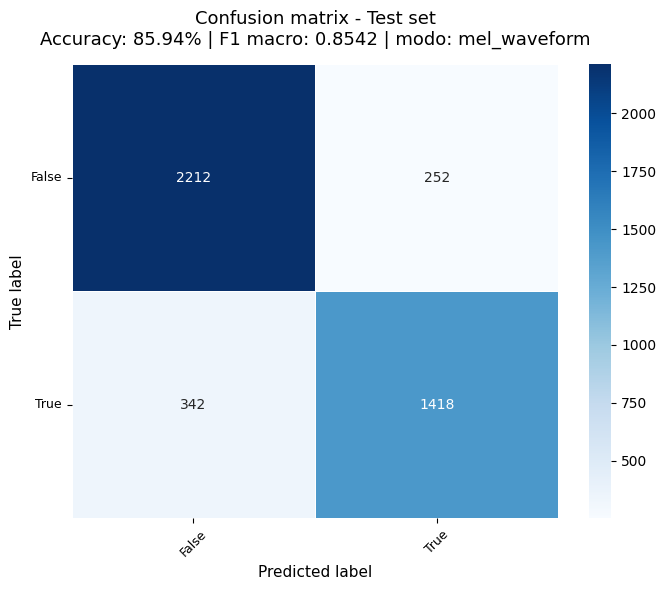

In [8]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.heatmap(
    cm,
    annot=ANNOT_ABSOLUTE,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title(
    f"Confusion matrix - Test set\nAccuracy: {acc:.2%} | F1 macro: {f1_mac:.4f} | modo: {MODE}",
    fontsize=13, pad=14,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()

save_path = FINAL_MODEL_DIR / "confusion_matrix_absolute.png"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
fig.savefig(save_path, dpi=180, bbox_inches="tight")
print(f"Guardada en: {save_path}")

plt.show()

## **9. Matriz de confusión normalizada por fila (recall por clase)**

Guardada en: /home/andres/Documentos/proyecto4geeks/models/final/confusion_matrix_normalized.png


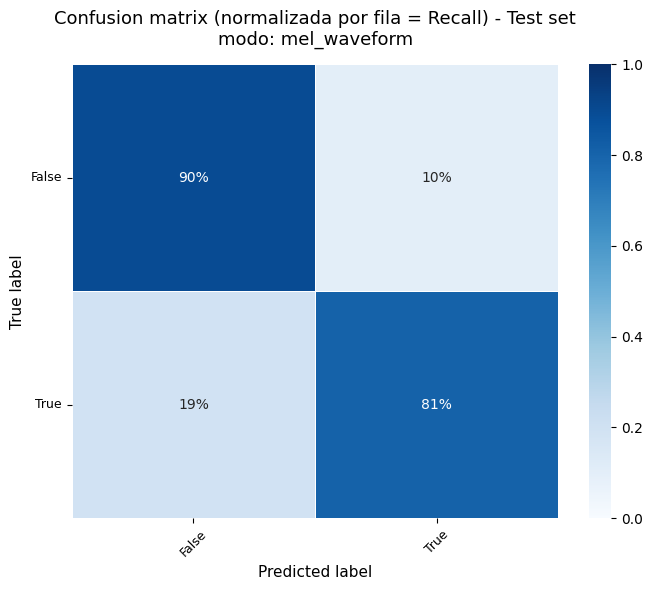

In [9]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=FIG_SIZE)

annot_data = (
    np.array([[f"{v:.0%}" for v in row] for row in cm_norm])
    if ANNOT_NORM else False
)

sns.heatmap(
    cm_norm,
    annot=annot_data if ANNOT_NORM else False,
    fmt="",
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title(
    f"Confusion matrix (normalizada por fila = Recall) - Test set\nmodo: {MODE}",
    fontsize=13, pad=14,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()

save_path_norm = FINAL_MODEL_DIR / "confusion_matrix_normalized.png"
fig.savefig(save_path_norm, dpi=180, bbox_inches="tight")
print(f"Guardada en: {save_path_norm}")

plt.show()

## **10. Clases con más errores**

Clases ordenadas por recall (de peor a mejor):


,Clase,Recall,Muestras test
0,True,80.57%,1760
1,False,89.77%,2464



Guardado en: /home/andres/Documentos/proyecto4geeks/models/final/recall_per_class.png


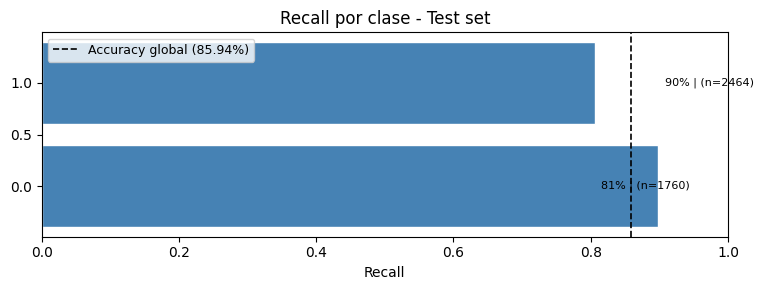

In [10]:
# Recall por clase (diagonal / total real de esa clase)
per_class_recall = cm.diagonal() / cm.sum(axis=1).clip(min=1)

# Cuántas muestras reales tiene cada clase
support = cm.sum(axis=1)

df_perf = (
    pd.DataFrame({
        "class": class_names,
        "recall": per_class_recall,
        "support": support,
    })
    .sort_values("recall")
    .reset_index(drop=True)
)

df_perf["recall_fmt"] = df_perf["recall"].map("{:.2%}".format)

print("Clases ordenadas por recall (de peor a mejor):")
display(df_perf[["class", "recall_fmt", "support"]].rename(
    columns={"class": "Clase", "recall_fmt": "Recall", "support": "Muestras test"}
))

# Barplot
fig, ax = plt.subplots(figsize=(8, 3))

colors = ["crimson" if r < 0.5 else "coral" if r < 0.7 else "steelblue"
          for r in df_perf["recall"]]

ax.barh(df_perf["class"], df_perf["recall"], color=colors, edgecolor="white")
ax.axvline(x=acc, color="black", linestyle="--", linewidth=1.2, label=f"Accuracy global ({acc:.2%})")
ax.set_xlim(0, 1)
ax.set_xlabel("Recall")
ax.set_title("Recall por clase - Test set")
ax.legend(fontsize=9)

for i, (r, sup) in enumerate(zip(df_perf["recall"], df_perf["support"])):
    ax.text(min(r + 0.01, 0.97), i, f"{r:.0%} | (n={sup})", va="center", fontsize=8)

plt.tight_layout()

save_path_bar = FINAL_MODEL_DIR / "recall_per_class.png"
fig.savefig(save_path_bar, dpi=150, bbox_inches="tight")
print(f"\nGuardado en: {save_path_bar}")

plt.show()

## **11. Confusiones más frecuentes (top errores)**

In [11]:
# Extraer pares (real, predicho) con más confusiones (fuera de la diagonal)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = [
    {
        "true": class_names[i],
        "predicted": class_names[j],
        "count": cm_off[i, j],
        "recall_true": f"{per_class_recall[i]:.0%}",
    }
    for i in range(NUM_CLASSES)
    for j in range(NUM_CLASSES)
    if cm_off[i, j] > 0
]

df_errors = (
    pd.DataFrame(pairs)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
    .head(20)
)

print("Top-20 confusiones (real --> predicho):")
display(df_errors)

Top-20 confusiones (real --> predicho):


,true,predicted,count,recall_true
0,True,False,342,81%
1,False,True,252,90%
